## Project 5: Storytelling Data Visualization on Exchange Rates

Target: analyse the exchange rate from euros to us dollars and euros to pound

Source: https://www.kaggle.com/lsind18/euro-exchange-daily-rates-19992020

I. Opening dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
exchange_rates = pd.read_csv('euro-daily-hist_1999_2021.csv')
pd.set_option('max_columns',exchange_rates.shape[1])
exchange_rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              5878 non-null   object 
 1   [Argentine peso ]         5383 non-null   object 
 2   [Australian dollar ]      5878 non-null   object 
 3   [Bulgarian lev ]          5476 non-null   object 
 4   [Brazilian real ]         5610 non-null   object 
 5   [Canadian dollar ]        5878 non-null   object 
 6   [Swiss franc ]            5878 non-null   object 
 7   [Chinese yuan renminbi ]  5610 non-null   object 
 8   [Cypriot pound ]          2346 non-null   object 
 9   [Czech koruna ]           5878 non-null   object 
 10  [Danish krone ]           5878 non-null   object 
 11  [Algerian dinar ]         5383 non-null   object 
 12  [Estonian kroon ]         3130 non-null   object 
 13  [UK pound sterling ]      5878 non-null   object 
 14  [Greek d

In [2]:
exchange_rates.head(2)

,Period\Unit:,[Argentine peso ],[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],[Algerian dinar ],[Estonian kroon ],[UK pound sterling ],[Greek drachma ],[Hong Kong dollar ],[Croatian kuna ],[Hungarian forint ],[Indonesian rupiah ],[Israeli shekel ],[Indian rupee ],[Iceland krona ],[Japanese yen ],[Korean won ],[Lithuanian litas ],[Latvian lats ],[Moroccan dirham ],[Maltese lira ],[Mexican peso ],[Malaysian ringgit ],[Norwegian krone ],[New Zealand dollar ],[Philippine peso ],[Polish zloty ],[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[New Taiwan dollar ],[US dollar ],[South African rand ]
0,2021-09-20,NaN,1.6201,1.9558,6.2495,1.5056,1.0883,7.5726,NaN,25.432,7.4359,NaN,NaN,0.85705,NaN,9.1188,7.5055,353.97,16742.86,3.7635,86.2720,152.0,128.18,1393.32,NaN,NaN,NaN,NaN,23.6419,4.9098,10.2430,1.6694,58.845,4.5997,4.9493,86.0700,10.2173,1.5839,NaN,NaN,39.0620,10.1512,NaN,1.1711,17.3301
1,2021-09-17,NaN,1.6111,1.9558,6.2039,1.4913,1.0931,7.6044,NaN,25.296,7.4360,NaN,NaN,0.85363,NaN,9.1691,7.5092,351.49,16762.90,3.7752,86.5335,151.4,129.61,1386.26,NaN,NaN,NaN,NaN,23.4722,4.9140,10.1208,1.6658,58.819,4.5804,4.9488,85.4338,10.1553,1.5851,NaN,NaN,39.1450,10.1323,NaN,1.1780,17.1891


In [3]:
exchange_rates.tail(2)

,Period\Unit:,[Argentine peso ],[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],[Algerian dinar ],[Estonian kroon ],[UK pound sterling ],[Greek drachma ],[Hong Kong dollar ],[Croatian kuna ],[Hungarian forint ],[Indonesian rupiah ],[Israeli shekel ],[Indian rupee ],[Iceland krona ],[Japanese yen ],[Korean won ],[Lithuanian litas ],[Latvian lats ],[Moroccan dirham ],[Maltese lira ],[Mexican peso ],[Malaysian ringgit ],[Norwegian krone ],[New Zealand dollar ],[Philippine peso ],[Polish zloty ],[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[New Taiwan dollar ],[US dollar ],[South African rand ]
5876,1999-01-05,NaN,1.8944,NaN,NaN,1.7965,1.6123,NaN,0.58230,34.917,7.4495,NaN,15.6466,0.71220,324.70,9.1341,NaN,250.80,9314.51,NaN,NaN,81.53,130.96,1373.01,4.71740,0.6657,NaN,0.4432,11.5960,4.4805,8.7745,2.2011,44.745,4.0245,1.3168,26.5876,9.4025,1.9655,188.7750,42.848,42.5048,0.3728,NaN,1.1790,6.7975
5877,1999-01-04,NaN,1.9100,NaN,NaN,1.8004,1.6168,NaN,0.58231,35.107,7.4501,NaN,15.6466,0.71110,327.15,9.1332,NaN,251.48,9433.61,NaN,NaN,81.48,133.73,1398.59,4.71700,0.6668,NaN,0.4432,11.6446,4.4798,8.8550,2.2229,45.510,4.0712,1.3111,25.2875,9.4696,1.9554,189.0450,42.991,42.6799,0.3723,NaN,1.1789,6.9358


In [4]:
exchange_rates.rename(columns = {'[US dollar ]':'US_dollar',
                                 'Period\\Unit:':'Time',
                                 '[UK pound sterling ]' :'UK_pound'},
                        inplace = True)
exchange_rates['Time'] = pd.to_datetime(exchange_rates['Time'])

In [5]:
#https://realpython.com/python-f-strings/
#https://gist.github.com/minism/1590432
print(f'\033[1mNumber of rows:\033[0m\t\t {exchange_rates.shape[0]:,}\n'
      f'\033[1mNumber of columns:\033[0m\t {exchange_rates.shape[1]:,}\n'
      f'\033[1mMissing data:\033[0m\n{round(exchange_rates.isnull().sum()*100/len(exchange_rates))}\n'
      f'\033[1mData type:\033[0m\n{exchange_rates.dtypes}')

Number of rows:		 5,878
Number of columns:	 45
Missing data:
Time                         0.0
[Argentine peso ]            8.0
[Australian dollar ]         0.0
[Bulgarian lev ]             7.0
[Brazilian real ]            5.0
[Canadian dollar ]           0.0
[Swiss franc ]               0.0
[Chinese yuan renminbi ]     5.0
[Cypriot pound ]            60.0
[Czech koruna ]              0.0
[Danish krone ]              0.0
[Algerian dinar ]            8.0
[Estonian kroon ]           47.0
UK_pound                     0.0
[Greek drachma ]            91.0
[Hong Kong dollar ]          0.0
[Croatian kuna ]             5.0
[Hungarian forint ]          0.0
[Indonesian rupiah ]         0.0
[Israeli shekel ]            5.0
[Indian rupee ]              5.0
[Iceland krona ]            41.0
[Japanese yen ]              0.0
[Korean won ]                0.0
[Lithuanian litas ]         29.0
[Latvian lats ]             34.0
[Moroccan dirham ]           8.0
[Maltese lira ]             60.0
[Mexican peso ]

In [6]:
euro_dollar = exchange_rates[['Time','US_dollar']]
euro_pound = exchange_rates[['Time','UK_pound']]
euro_dollar['US_dollar'].value_counts()

-         62
1.2276     9
1.1215     8
1.1305     7
1.1346     6
          ..
0.8983     1
1.2658     1
1.4921     1
1.2467     1
1.1986     1
Name: US_dollar, Length: 3576, dtype: int64

In [7]:
euro_pound['UK_pound'].value_counts()

-          62
0.67930     7
0.68880     7
0.90430     7
0.84560     7
           ..
0.90228     1
0.83310     1
0.88668     1
0.85638     1
0.87180     1
Name: UK_pound, Length: 3567, dtype: int64

In [8]:
euro_dollar = euro_dollar[euro_dollar['US_dollar']!='-']
euro_dollar['US_dollar'] = euro_dollar['US_dollar'].astype('float')
euro_pound = euro_pound[euro_pound['UK_pound']!='-']
euro_pound['UK_pound'] = euro_pound['UK_pound'].astype('float')
euro_dollar['US_dollar'].value_counts(bins=10)

(1.057, 1.135]    1141
(1.289, 1.367]    1046
(1.135, 1.212]     998
(1.212, 1.289]     905
(1.367, 1.444]     476
(0.823, 0.903]     333
(0.903, 0.98]      302
(0.98, 1.057]      292
(1.444, 1.522]     215
(1.522, 1.599]     108
Name: US_dollar, dtype: int64

In [9]:
euro_pound['UK_pound'].value_counts(bins=10)

(0.856, 0.897]    1324
(0.653, 0.693]    1103
(0.816, 0.856]     840
(0.612, 0.653]     674
(0.775, 0.816]     588
(0.693, 0.734]     508
(0.897, 0.938]     390
(0.57, 0.612]      201
(0.734, 0.775]     172
(0.938, 0.979]      16
Name: UK_pound, dtype: int64

In [10]:
#https://en.wikipedia.org/wiki/Moving_average
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html
euro_dollar['rolling_mean'] = euro_dollar['US_dollar'].rolling(30).mean()

In [11]:
euro_dollar.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5816 entries, 0 to 5877
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Time          5816 non-null   datetime64[ns]
 1   US_dollar     5816 non-null   float64       
 2   rolling_mean  5787 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 181.8 KB


Now we'll plot 2 graphs: EUR-USD exchange rate evolution with and without smoothing to see the difference: 

In [12]:
columns = ['US_dollar','rolling_mean']
titles = ['EUR-USD exchange rate evolution \nwithout rolling mean',
          'EUR-USD exchange rate evolution \nwith rolling mean']
def create_line(df,title,xlabel='Month',column='rolling_mean',title_font=25,label_font=20,
                tick_font=14,x_min ='1999-01-01',x_max ='2021-09-20',y_min=None,y_max=None):
    plt.plot(df['Time'],df[column],color='blue')
    plt.title(title,fontsize=title_font)
    plt.xlabel(xlabel,fontsize=label_font)
    plt.ylabel('Exchange rate',fontsize = label_font)
    plt.xticks(fontsize = tick_font)
    plt.yticks(fontsize = tick_font)
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    sns.despine()

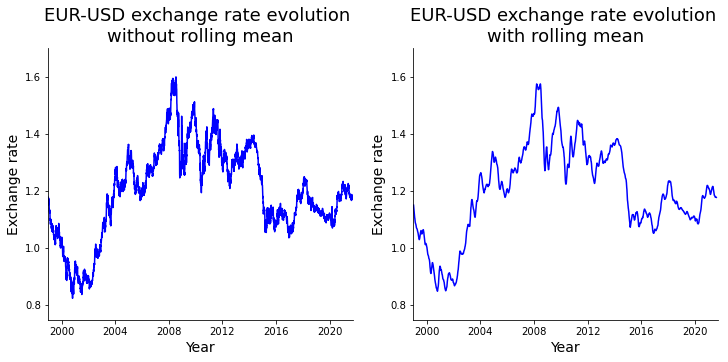

In [13]:
plt.figure(figsize=(12,5))
for i in range (1,3):
    plt.subplot(1,2,i)
    create_line(df = euro_dollar, title = titles[i-1], xlabel = 'Year',column=columns[i-1],
                title_font = 18, label_font = 14, tick_font = None,y_min = 0.75,y_max=1.7)


In [14]:
columns2 = ['UK_pound','rolling_mean']
titles2 = ['EUR-GDP exchange rate evolution \nwithout rolling mean',
          'EUR-GDP exchange rate evolution \nwith rolling mean']


In [15]:
euro_pound['rolling_mean'] = euro_pound['UK_pound'].rolling(30).mean()
euro_pound.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5816 entries, 0 to 5877
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Time          5816 non-null   datetime64[ns]
 1   UK_pound      5816 non-null   float64       
 2   rolling_mean  5787 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 181.8 KB


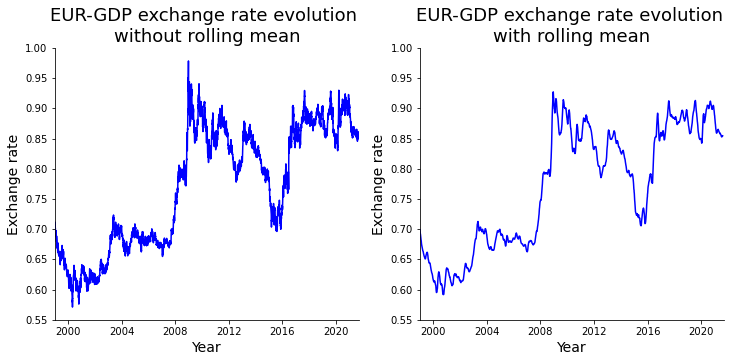

In [16]:
plt.figure(figsize=(12,5))
for i in range (1,3):
    plt.subplot(1,2,i)
    create_line(df = euro_pound, title = titles2[i-1], xlabel = 'Year',column=columns2[i-1],
                title_font = 18, label_font = 14, tick_font = None,y_min = 0.55,y_max=1)

In [17]:
crisis=euro_dollar.copy()[(euro_dollar['Time'].dt.year >=2006)&(euro_dollar['Time'].dt.year<=2009)]
crisis_78 = euro_dollar.copy()[(euro_dollar['Time'].dt.year >=2007)&(euro_dollar['Time'].dt.year<=2008)]

In [18]:
crisis.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1022 entries, 3009 to 4052
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Time          1022 non-null   datetime64[ns]
 1   US_dollar     1022 non-null   float64       
 2   rolling_mean  1022 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 31.9 KB


In [19]:
crisis_78.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 511 entries, 3270 to 3791
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Time          511 non-null    datetime64[ns]
 1   US_dollar     511 non-null    float64       
 2   rolling_mean  511 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 16.0 KB


13077.05
14681.95


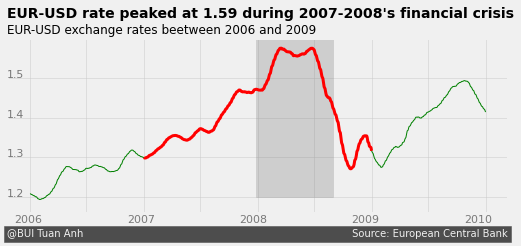

In [20]:
#https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html
style.use('fivethirtyeight')
fig,ax = plt.subplots(figsize=(8,3))
ax.set_ylim(1.16,1.6)
ax.plot(crisis['Time'],crisis['rolling_mean'],linewidth=1,color='green')
ax.plot(crisis_78['Time'],crisis_78['rolling_mean'],linewidth=3,color='red')
ax.set_xticklabels([])
ax.set_yticklabels([])
xmin,xmax=plt.xlim()
print(xmin)
print(xmax)

x=13100
for year in ['2006','2007','2008','2009','2010']:
    ax.text(x,1.135,year,alpha = 0.5,fontsize = 11)
    x += 360 
y = 1.2
for rate in ['1.2','1.3','1.4','1.5']:
    ax.text(13077,y,rate,alpha=0.5,fontsize = 11)
    y += 0.1 

ax.text(13077,1.65,"EUR-USD rate peaked at 1.59 during 2007-2008's financial crisis",weight = 'bold')
ax.text(13077,1.61,'EUR-USD exchange rates beetween 2006 and 2009', size = 12)
ax.text(13077,1.10,'@BUI Tuan Anh'+' '*86 +'Source: European Central Bank',color='#f0f0f0',backgroundcolor='#4d4d4d',size =10)

ax.axvspan(xmin=13875,xmax=14120,ymin=0.09,color='gray',alpha=0.3)
ax.grid(alpha=0.5)

In [21]:
usa_2020 = euro_dollar.copy()[(euro_dollar['Time'].dt.year==2020)]
phase_1 = usa_2020.copy()[usa_2020['Time']<='2020-03-15 00:00:00']
phase_2 = usa_2020.copy()[(usa_2020['Time']>'2020-03-15 00:00:00')&(usa_2020['Time']<='2020-05-15 00:00:00')]
phase_3 = usa_2020.copy()[(usa_2020['Time']>'2020-05-15 00:00:00')&(usa_2020['Time']<='2020-06-15 00:00:00')]
phase_4 = usa_2020.copy()[(usa_2020['Time']>'2020-06-15 00:00:00')&(usa_2020['Time']<='2020-08-15 00:00:00')]
phase_5 = usa_2020.copy()[(usa_2020['Time']>'2020-08-15 00:00:00')&(usa_2020['Time']<='2020-10-15 00:00:00')]
phase_6 = usa_2020.copy()[usa_2020['Time']>'2020-10-15 00:00:00']

18244.8
18645.2


Text(18232, 1.05, '@BUI Tuan Anh                                                                                                    Source: European Central Bank')

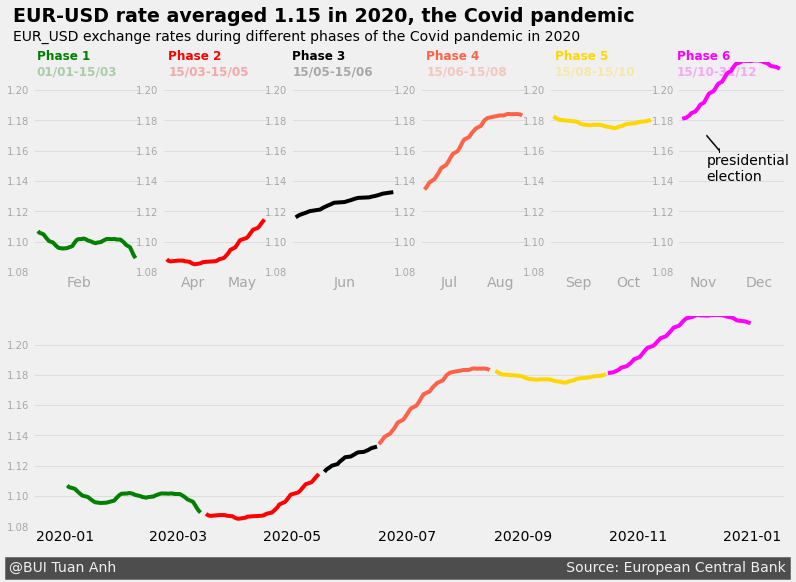

In [22]:
#https://towardsdatascience.com/a-beginners-guide-to-plotting-fivethrityeight-like-visualizations-5b63d3f3ddd0
style.use('fivethirtyeight')

plt.figure(figsize=(12,8))
ax1=plt.subplot(2,6,1)
ax2=plt.subplot(2,6,2)
ax3=plt.subplot(2,6,3)
ax4=plt.subplot(2,6,4)
ax5=plt.subplot(2,6,5)
ax6=plt.subplot(2,6,6)
ax7=plt.subplot(2,1,2)
axes=[ax1,ax2,ax3,ax4,ax5,ax6,ax7]
for ax in axes:
    ax.set_ylim(1.08,1.22)
    ax.set_yticks([1.08,1.10,1.12,1.14,1.16,1.18,1.20])
    ax.set_yticklabels(['1.08','1.10','1.12','1.14','1.16','1.18','1.20'],alpha=0.3,fontsize=10)
    ax.yaxis.grid(True,alpha = 0.50)
    ax.xaxis.grid(False)
    
ax1.plot(phase_1['Time'],phase_1['rolling_mean'],color = 'green')
ax1.set_xticklabels(['','','Feb','','','','Mar','',''],alpha = 0.3)

ax2.plot(phase_2['Time'],phase_2['rolling_mean'],color = 'red')
ax2.set_xticklabels(['','','Apr','','','','May','',''],alpha = 0.3)

ax3.plot(phase_3['Time'],phase_3['rolling_mean'],color = 'black')
ax3.set_xticklabels(['','','','','Jun','','','',''],alpha = 0.3)

ax4.plot(phase_4['Time'],phase_4['rolling_mean'],color = 'tomato')
ax4.set_xticklabels(['','','Jul','','','','Aug','',''],alpha = 0.3)

ax5.plot(phase_5['Time'],phase_5['rolling_mean'],color = 'gold')
ax5.set_xticklabels(['','','Sep','','','','Oct','',''],alpha = 0.3)

ax6.plot(phase_6['Time'],phase_6['rolling_mean'],color = 'magenta')
ax6.set_xticklabels(['','Nov','','','Dec',''],alpha = 0.3)

ax7.plot(phase_1['Time'],phase_1['rolling_mean'],color = 'green')
ax7.plot(phase_2['Time'],phase_2['rolling_mean'],color = 'red')
ax7.plot(phase_3['Time'],phase_3['rolling_mean'],color = 'black')
ax7.plot(phase_4['Time'],phase_4['rolling_mean'],color = 'tomato')
ax7.plot(phase_5['Time'],phase_5['rolling_mean'],color = 'gold')
ax7.plot(phase_6['Time'],phase_6['rolling_mean'],color = 'magenta')

xmin,xmax = plt.xlim()
print(xmin)
print(xmax)

ax1.text(18262,1.22,'Phase 1',fontsize = 12, weight = 'bold',color='green')
ax1.text(18262,1.21,'01/01-15/03',fontsize = 12, weight = 'bold',color='green',alpha=0.3)

ax2.text(18338,1.22,'Phase 2',fontsize = 12, weight = 'bold',color='red')
ax2.text(18338,1.21,'15/03-15/05',fontsize = 12, weight = 'bold',color='red',alpha=0.3)

ax3.text(18399,1.22,'Phase 3',fontsize = 12, weight = 'bold',color='black')
ax3.text(18399,1.21,'15/05-15/06',fontsize = 12, weight = 'bold',color='black',alpha=0.3)

ax4.text(18430,1.22,'Phase 4',fontsize = 12, weight = 'bold',color='tomato')
ax4.text(18430,1.21,'15/06-15/08',fontsize = 12, weight = 'bold',color='tomato',alpha=0.3)

ax5.text(18492,1.22,'Phase 5',fontsize = 12, weight = 'bold',color='gold')
ax5.text(18492,1.21,'15/08-15/10',fontsize = 12, weight = 'bold',color='gold',alpha=0.3)

ax6.text(18547,1.22,'Phase 6',fontsize = 12, weight = 'bold',color='magenta')
ax6.text(18547,1.21,'15/10-31/12',fontsize = 12, weight = 'bold',color='magenta',alpha=0.3)
ax6.arrow(18570,1.17,10,-0.01,color='black')
ax6.annotate('presidential\nelection',xy=(18570,1.14))

rate_avg = round(usa_2020['rolling_mean'].mean(),2)

ax1.text(18245,1.245,f'EUR-USD rate averaged {rate_avg} in 2020, the Covid pandemic',fontsize = 19, weight = 'bold')
ax1.text(18245,1.233,'EUR_USD exchange rates during different phases of the Covid pandemic in 2020',fontsize = 14)

ax7.text(18232,1.05,'@BUI Tuan Anh'+' '*100+'Source: European Central Bank',color='#f0f0f0',backgroundcolor='#4d4d4d',fontsize=14)


![USA_2020](USA_2020.jpg)

In [24]:
bush_obama_trump = euro_dollar.copy(
                   )[(euro_dollar['Time'].dt.year >= 2001) & (euro_dollar['Time'].dt.year < 2021)]
bush = bush_obama_trump.copy(
       )[bush_obama_trump['Time'].dt.year < 2009]
obama = bush_obama_trump.copy(
       )[(bush_obama_trump['Time'].dt.year >= 2009) & (bush_obama_trump['Time'].dt.year < 2017)]
trump = bush_obama_trump.copy(
       )[(bush_obama_trump['Time'].dt.year >= 2017) & (bush_obama_trump['Time'].dt.year < 2021)]

10958.85
18992.15


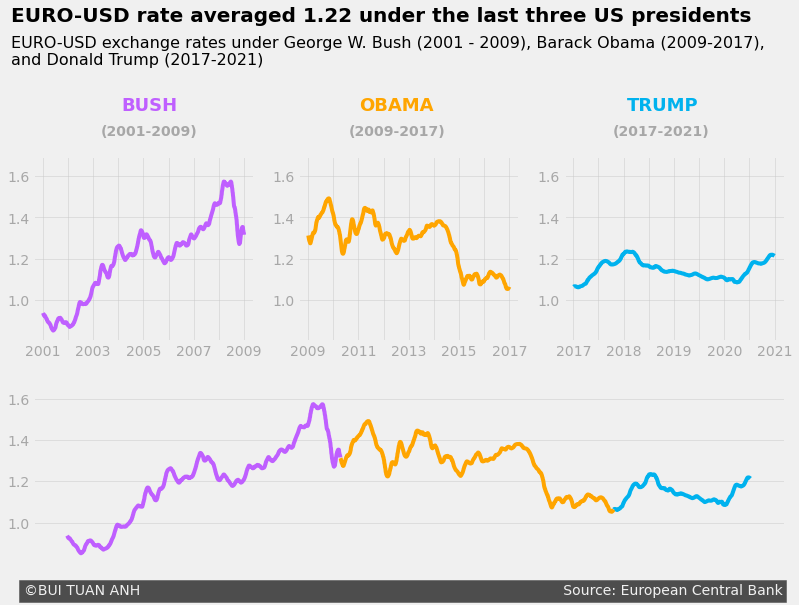

In [25]:
### Adding the FiveThirtyEight style
style.use('fivethirtyeight')

### Adding the subplots
plt.figure(figsize=(12, 7))
ax1 = plt.subplot(2,3,1)
ax2 = plt.subplot(2,3,2)
ax3 = plt.subplot(2,3,3)
ax4 = plt.subplot(2,1,2)
axes = [ax1, ax2, ax3, ax4]

### Changes to all the subplots
for ax in axes:
    ax.set_ylim(0.8, 1.7)
    ax.set_yticks([1.0, 1.2, 1.4, 1.6])
    ax.set_yticklabels(['1.0', '1.2','1.4', '1.6'],
                   alpha=0.3)
    ax.grid(alpha=0.5)    
    

### Ax1: Bush
ax1.plot(bush['Time'], bush['rolling_mean'],
        color='#BF5FFF')
ax1.set_xticklabels(['', '2001', '', '2003', '', '2005', '',
                     '2007', '', '2009'],
                   alpha=0.3)
### Ax2: Obama
ax2.plot(obama['Time'], obama['rolling_mean'],
        color='#ffa500')
ax2.set_xticklabels(['', '2009', '', '2011', '', '2013', '',
                     '2015', '', '2017'],
                   alpha=0.3)


### Ax3: Trump
ax3.plot(trump['Time'], trump['rolling_mean'],
        color='#00B2EE')
ax3.set_xticklabels(['2017', '', '2018', '', '2019', '',
                     '2020', '', '2021'],
                   alpha=0.3)


### Ax4: Bush-Obama-Trump
ax4.plot(bush['Time'], bush['rolling_mean'],
        color='#BF5FFF')
ax4.plot(obama['Time'], obama['rolling_mean'],
        color='#ffa500')
ax4.plot(trump['Time'], trump['rolling_mean'],
        color='#00B2EE')
ax4.grid(alpha=0.5)
ax4.set_xticks([])

xmin, xmax = plt.xlim()
print(xmin)
print(xmax)

ax1.text(12458.0, 1.92, 'BUSH', fontsize=18, weight='bold',
        color='#BF5FFF')
ax1.text(12158.0, 1.8, '(2001-2009)', weight='bold',
        alpha=0.3)
ax2.text(14988.0, 1.92, 'OBAMA', fontsize=18, weight='bold',
        color='#ffa500')
ax2.text(14838.0, 1.8, '(2009-2017)', weight='bold',
         alpha=0.3)
ax3.text(17555.0, 1.92, 'TRUMP', fontsize=18, weight='bold',
        color='#00B2EE')
ax3.text(17455.0, 1.8, '(2017-2021)', weight='bold',
         alpha=0.3)
### Adding a title and a subtitle
ax1.text(10858.0, 2.35, 'EURO-USD rate averaged 1.22 under the last three US presidents',
         fontsize=20, weight='bold')
ax1.text(10858.0, 2.14, '''EURO-USD exchange rates under George W. Bush (2001 - 2009), Barack Obama (2009-2017),
and Donald Trump (2017-2021)''',
        fontsize=16)

### Adding a signature
ax4.text(10858.0, 0.65, '©BUI TUAN ANH' + ' '*94 + 'Source: European Central Bank',
        color = '#f0f0f0', backgroundcolor = '#4d4d4d',
        size=14)
plt.show()

18233.7
18878.3


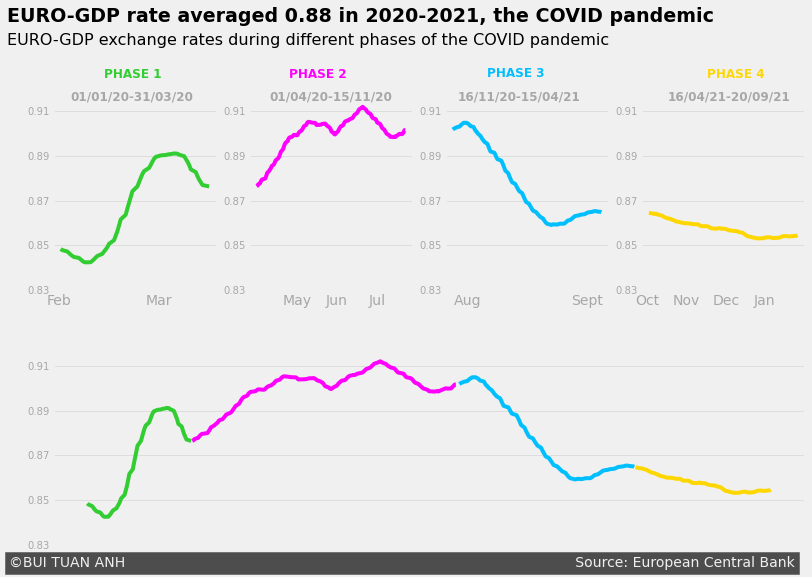

In [28]:
covid_uk = euro_pound.copy()[(euro_pound['Time'].dt.year==2020)|(euro_pound['Time'].dt.year==2021)]


# Creating a dataframe for each COVID phase in uksia in 2020
beginning_uk = covid_uk.copy()[(covid_uk['Time']>='2020-01-01 00:00:00')&
                                 (covid_uk['Time']<='2020-03-31 00:00:00')]
wave_1_uk = covid_uk.copy()[(covid_uk['Time']>='2020-04-01 00:00:00')&
                              (covid_uk['Time']<='2020-11-15 00:00:00')]
plateau_uk = covid_uk.copy()[(covid_uk['Time']>='2020-11-16 00:00:00')&
                               (covid_uk['Time']<='2021-04-15 00:00:00')]
wave_2_uk = covid_uk.copy()[covid_uk['Time']>='2021-04-16 00:00:00']
#_________________________________________________________________

# Creating a storytelling data visualization for the EUR-gdp rate evolution
# during the COVID pandemic in uksia in 2020
style.use('fivethirtyeight')

plt.figure(figsize=(12,8))
ax1 = plt.subplot(2,4,1)
ax2 = plt.subplot(2,4,2)
ax3 = plt.subplot(2,4,3)
ax4 = plt.subplot(2,4,4)
ax5 = plt.subplot(2,1,2)
axes = [ax1, ax2, ax3, ax4, ax5]

for ax in axes:
    ax.set_ylim(0.83, 0.925)
    ax.set_yticks([0.83,0.85,0.87,0.89,0.91])
    ax.set_yticklabels(['0.83','0.85','0.87','0.89','0.91'], alpha=0.3, fontsize=10)
    ax.yaxis.grid(True, alpha=0.5)
    ax.xaxis.grid(False)
    
ax1.plot(beginning_uk['Time'], beginning_uk['rolling_mean'], color='limegreen')
ax1.set_xticklabels(['Feb', '', '', '', 'Mar', '', '', '', 'Apr'], alpha=0.3)




ax2.plot(wave_1_uk['Time'], wave_1_uk['rolling_mean'], color='magenta')
ax2.set_xticklabels(['', '', 'May', '', 'Jun', '', 'Jul', ''], alpha=0.3)



ax3.plot(plateau_uk['Time'], plateau_uk['rolling_mean'], color='deepskyblue')
ax3.set_xticklabels(['Aug', '', '', '', 'Sept', '', '', ''], alpha=0.3)


ax4.plot(wave_2_uk['Time'], wave_2_uk['rolling_mean'], color='gold')
ax4.set_xticklabels(['Oct', '', 'Nov', '', 'Dec', '', 'Jan'], alpha=0.3)


ax5.plot(beginning_uk['Time'], beginning_uk['rolling_mean'], color='limegreen')
ax5.plot(wave_1_uk['Time'], wave_1_uk['rolling_mean'], color='magenta')
ax5.plot(plateau_uk['Time'], plateau_uk['rolling_mean'], color='deepskyblue')
ax5.plot(wave_2_uk['Time'], wave_2_uk['rolling_mean'], color='gold')
ax5.set_xticks([])

rate_avg_uk = round(covid_uk['rolling_mean'].mean(),2)
xmin, xmax = plt.xlim()
print(xmin)
print(xmax)


ax1.text(18289, 0.925, 'PHASE 1', fontsize=12, weight='bold', color='limegreen')
ax1.text(18269, 0.915, '01/01/20-31/03/20', fontsize=12, weight='bold', alpha=0.3)
ax2.text(18402, 0.925, 'PHASE 2', fontsize=12, weight='bold', color='magenta')
ax2.text(18372, 0.915, '01/04/20-15/11/20', fontsize=12, weight='bold', alpha=0.3)
ax3.text(18617, 0.9253,'PHASE 3', fontsize=12, weight='bold', color='deepskyblue')
ax3.text(18587, 0.915, '16/11/20-15/04/21', fontsize=12, weight='bold', alpha=0.3)
ax4.text(18778, 0.925, 'PHASE 4', fontsize=12, weight='bold', color='gold')
ax4.text(18748, 0.915, '16/04/21-20/09/21', fontsize=12, weight='bold', alpha=0.3)

ax1.text(18231, 0.95, f'EURO-GDP rate averaged {rate_avg_uk} in 2020-2021, the COVID pandemic',
         fontsize=19, weight='bold')
ax1.text(18231, 0.94, '''EURO-GDP exchange rates during different phases of the COVID pandemic''', fontsize=16)
ax5.text(18196, 0.82, '©BUI TUAN ANH' + ' '*100 + 'Source: European Central Bank',
        color='#f0f0f0', backgroundcolor='#4d4d4d', size=14)
plt.show()


![uk_eu](UK_EU.jpg)